# [ML] ALS vs ALS+Twiddler 오프라인 성능 비교 (현재 로직) — 2026-07-08

**목적**: 현재 프로덕션에 반영된 최종 Twiddler 로직(Rule 1 v3 + Rule 2 v3, Rule 3 제거)을 기준으로
ALS 단독 추천과 ALS+Twiddler 추천의 오프라인 성능(정확도·다양성)을 비교하고, 각 하이퍼파라미터가
무엇을 의미하며 무엇을 반영하려 했는지 정리한다.

이 노트북은 로직을 새로 구현하지 않는다 — `backend/api/services/persona_service.py`,
`src/modeling/twiddler/rerank.py`를 그대로 import해서 쓴다. 노트북이 실제 서빙 코드와
항상 일치하도록 하기 위함이다(재구현 시 노트북과 실제 코드가 따로 놀 위험을 없앤다).

| 항목 | 내용 |
|---|---|
| 데이터셋 | `data/outputs/ALS/PRED_MAIN_RECOMMEND.csv` (dataset=full, 유저별 top-100 ALS 추천) |
| 정답셋 | `data/outputs/ALS/als_test.csv` (split_date=2025-08-01 이후 **purchase** 이벤트만) |
| 페르소나 | `data/processed/customer_segments_labeled_train_only.csv` (train 기간 기준, 유저 단위 원본 컬럼) |
| 평가 지표 | 정확도: HR@K·Recall@K·NDCG@K (K=5,10,20) / 다양성: 세션 간 아이템 중복률, 고유 아이템 비율, 카테고리 커버리지 |
| 재현성 | `random_state=42` 고정 |

**핵심 가정 및 방법론적 제약**
- 이 데이터셋은 Faker 기반 합성 데이터다 — "가치관 반영"이라는 표현은 실제로는 "행동 성향 프록시(카테고리 로열티, 탐색성향) 반영"으로 좁혀 해석해야 한다.
- Rule 3(저노출 상품 최소 노출 보장)은 유저 페르소나와 무관한 아이템 공급측 형평성 장치로 판단해 코드에서 완전히 제거했다(연구질문과 무관, 실측 효과도 낮음 — `configs/twiddler/params.yaml` 주석 참고). 이 노트북 비교에는 해당하지 않는다.
- 단일 세션(1회 추천) 평가에서는 Rule 2(노출 이력 패널티)가 사실상 작동하지 않는다 — 노출 이력이 없는 첫 요청이기 때문이다. Rule 2의 효과는 반복 새로고침 시뮬레이션에서만 나타난다.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from backend.api.services import persona_service, catalog_service
from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "Malgun Gothic",  # Windows 한국어 폰트. Mac은 'AppleGothic', Linux는 'NanumGothic'
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
})

np.random.seed(42)

OUTPUT_DIR = REPO_ROOT / "data" / "outputs" / "ALS"
K_LIST = [5, 10, 20]
T_SESSIONS = 5  # 반복 새로고침 횟수
POOL_MULTIPLIER = rerank_mod.POOL_MULTIPLIER

## 1. 하이퍼파라미터가 의미하는 것

`configs/twiddler/params.yaml`을 그대로 로드해서 확인한다 — 노트북에 값을 하드코딩하지 않고
실제 서빙에 쓰이는 설정 파일을 직접 읽는다.

In [2]:
with open(REPO_ROOT / "configs" / "twiddler" / "params.yaml", "r", encoding="utf-8") as f:
    twiddler_params = yaml.safe_load(f)
for k, v in twiddler_params.items():
    print(f"{k}: {v}")

num_categories: 7
base_alpha: 1.5
multiplier_floor: 0.3
multiplier_ceiling: 1.7
exposure_decay: 0.7
exploration_decay_min: 0.5
exploration_decay_max: 0.85
pool_multiplier: 3

**Rule 1 — 페르소나 카테고리 가중치 (개인화)**

| 파라미터 | 값 | 의미 | 반영하고자 한 것 |
|---|---|---|---|
| `num_categories` | 7 | 카탈로그 전체 카테고리 수 | "이 카테고리를 특별히 좋아하지도 싫어하지도 않는 상태"(균등분포 1/7)를 편차 계산의 기준점으로 삼기 위함 |
| `base_alpha` | 1.5 | Rule 1이 낼 수 있는 **최대** 강도 | 실제 개인화 alpha = `base_alpha × category_loyalty × (1-exploration_tendency)`. 유저가 한 카테고리에 완전히 충성(loyalty=1)하면서 전혀 탐색하지 않을 때(exploration=0)만 이 값 그대로 쓰이고, 그 외에는 자동으로 낮아진다 |
| `multiplier_floor` | 0.3 | 최종 배율의 **하한** | 아무리 관심 밖 카테고리라도 점수를 0에 가깝게 죽이지 않는다(최소 노출 보장) |
| `multiplier_ceiling` | 1.7 | 최종 배율의 **상한**(2−floor로 대칭 유도) | 로열티가 매우 높은 유저의 alpha가 무한정 커져 한 카테고리에만 갇히는(필터버블) 것을 방지 — 상한이 없어 다양성이 떨어졌던 것을 검증 후 추가했다 |

**Rule 2 — 노출 이력 패널티 (개인화)**

| 파라미터 | 값 | 의미 | 반영하고자 한 것 |
|---|---|---|---|
| `exposure_decay` | 0.7 | 페르소나 데이터가 없는 유저용 **fallback** 고정 감쇠율 | 개인화 정보가 없을 때도 최소한의 노출 다양성은 유지 |
| `exploration_decay_min` | 0.5 | 탐색성향이 가장 높은 유저의 감쇠율 | 다양한 카테고리를 넘나드는 유저는 빨리 잊고 새 아이템을 더 적극적으로 보여준다 |
| `exploration_decay_max` | 0.85 | 탐색성향이 가장 낮은 유저의 감쇠율 | 한 가지를 꾸준히 찾는 유저는 천천히 잊고 익숙한 아이템을 유지해준다 |
| `pool_multiplier` | 3 | 최종 top_k의 3배를 후보 풀로 미리 확보 | Rule 1/2가 재배치할 여지(자리)를 충분히 준다 |

**Rule 1/2가 공유하는 유저 단위 파생 피처** (`persona_service.py`가 계산, YAML 파라미터는 아니지만 위 값들이 실제로 작동하는 대상)

- **`category_loyalty`**(0~1) = `dominant_purchase_category_ratio` — 이 유저의 구매가 얼마나 한 카테고리에 집중돼 있는지. 구매 이력이 없으면 0(→ Rule 1이 사실상 비활성화되어, 근거 없이 카테고리를 밀어주지 않는다).
- **`exploration_tendency`**(0~1) — 유저가 익숙한 채널을 넘어 얼마나 탐색적으로 행동하는지. 구매 이력이 있으면 `category_diversity_purchase`(구매 카테고리 다양성)와 `(1-view_purchase_category_match)`(조회-구매 카테고리 불일치)를 절반씩 결합하고, 구매 이력이 없으면 `dominant_view_category_ratio`의 역수로 근사한다(데이터 없이 임의로 가정하지 않기 위한 분기).

**Rule 1 alpha와 Rule 2 decay는 같은 `exploration_tendency`를 반대 방향으로 쓴다** — 탐색성향이 높을수록 Rule 1은 약하게(카테고리 고정 완화), Rule 2는 빠르게(노출 다양성 확대) 작동해, "탐색형 유저에게는 다양성을, 충성형 유저에게는 익숙함을"이라는 하나의 설계 의도를 두 Rule이 함께 구현한다.

## 2. 데이터 로드 & 검증

In [3]:
recs_df = pd.read_csv(OUTPUT_DIR / "PRED_MAIN_RECOMMEND.csv")
test_df = pd.read_csv(OUTPUT_DIR / "als_test.csv")

print("[검증] PRED_MAIN_RECOMMEND.csv")
print(f"  shape={recs_df.shape}, null 비율:\n{(recs_df.isna().mean()*100).round(2).to_dict()}")
print(f"  중복 행 수: {recs_df.duplicated().sum()}")

ground_truth = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
eval_users = list(ground_truth.keys())
category_map = catalog_service.get_category_map()
user_type_map = recs_df.drop_duplicates("user_id").set_index("user_id")["user_type"].to_dict()

recs_by_user = {
    uid: g.sort_values("rank")[["item_id", "score"]].to_dict("records")
    for uid, g in recs_df[recs_df["user_id"].isin(eval_users)].groupby("user_id")
}
print(f"\n평가 대상 유저 수: {len(eval_users):,}명 "
      f"(heavy={sum(1 for u in eval_users if user_type_map.get(u)=='heavy')}, "
      f"cold={sum(1 for u in eval_users if user_type_map.get(u)=='cold')})")

[검증] PRED_MAIN_RECOMMEND.csv
  shape=(1993000, 5), null 비율:
{'user_id': 0.0, 'item_id': 0.0, 'score': 0.0, 'rank': 0.0, 'user_type': 0.0}
  중복 행 수: 0

평가 대상 유저 수: 1,463명 (heavy=1427, cold=36)

## 3. 단일 세션(1회 추천) 정확도: ALS only vs ALS+Twiddler

실제 서빙 코드(`backend/api/services/twiddler_service.py`)와 동일한 순서로 호출한다:
`persona_service.get_persona` → `get_user_affinity`/`get_user_alpha` → `rerank_mod.rerank`.
`exposure_counts=None`이라 Rule 2는 이 단계에서 작동하지 않는다(첫 요청 가정).

In [4]:
def apply_current_twiddler(candidates, uid, k):
    persona_label = persona_service.get_persona(uid)
    if persona_label is None:
        return [it["item_id"] for it in candidates[:k]]
    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    reranked = rerank_mod.rerank(
        candidates, id_key="item_id", category_map=category_map,
        affinity=affinity, alpha=alpha, exposure_counts=None, top_k=k,
    )
    return [it["item_id"] for it in reranked]


def single_session_metrics(k, condition):
    pool_n = k * POOL_MULTIPLIER
    hr_list, recall_list, ndcg_list = [], [], []
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates = [dict(it) for it in recs_by_user[uid][:pool_n]]
        if condition == "als_only":
            recommended = [it["item_id"] for it in candidates[:k]]
        else:
            recommended = apply_current_twiddler(candidates, uid, k)
        true_items = ground_truth[uid]
        hr_list.append(hit_rate_at_k(recommended, true_items))
        recall_list.append(recall_at_k(recommended, true_items))
        ndcg_list.append(ndcg_at_k(recommended, true_items))
    return {"k": k, "condition": condition, "HR": round(np.mean(hr_list), 4),
            "Recall": round(np.mean(recall_list), 4), "NDCG": round(np.mean(ndcg_list), 4),
            "eval_users": len(hr_list)}


baseline_rows = [single_session_metrics(k, c) for k in K_LIST for c in ["als_only", "als_twiddler"]]
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

 k    condition     HR  Recall   NDCG  eval_users
 5     als_only 0.0171  0.0098 0.0075        1463
 5 als_twiddler 0.0205  0.0111 0.0083        1463
10     als_only 0.0369  0.0202 0.0114        1463
10 als_twiddler 0.0335  0.0188 0.0110        1463
20     als_only 0.0608  0.0330 0.0152        1463
20 als_twiddler 0.0602  0.0334 0.0154        1463

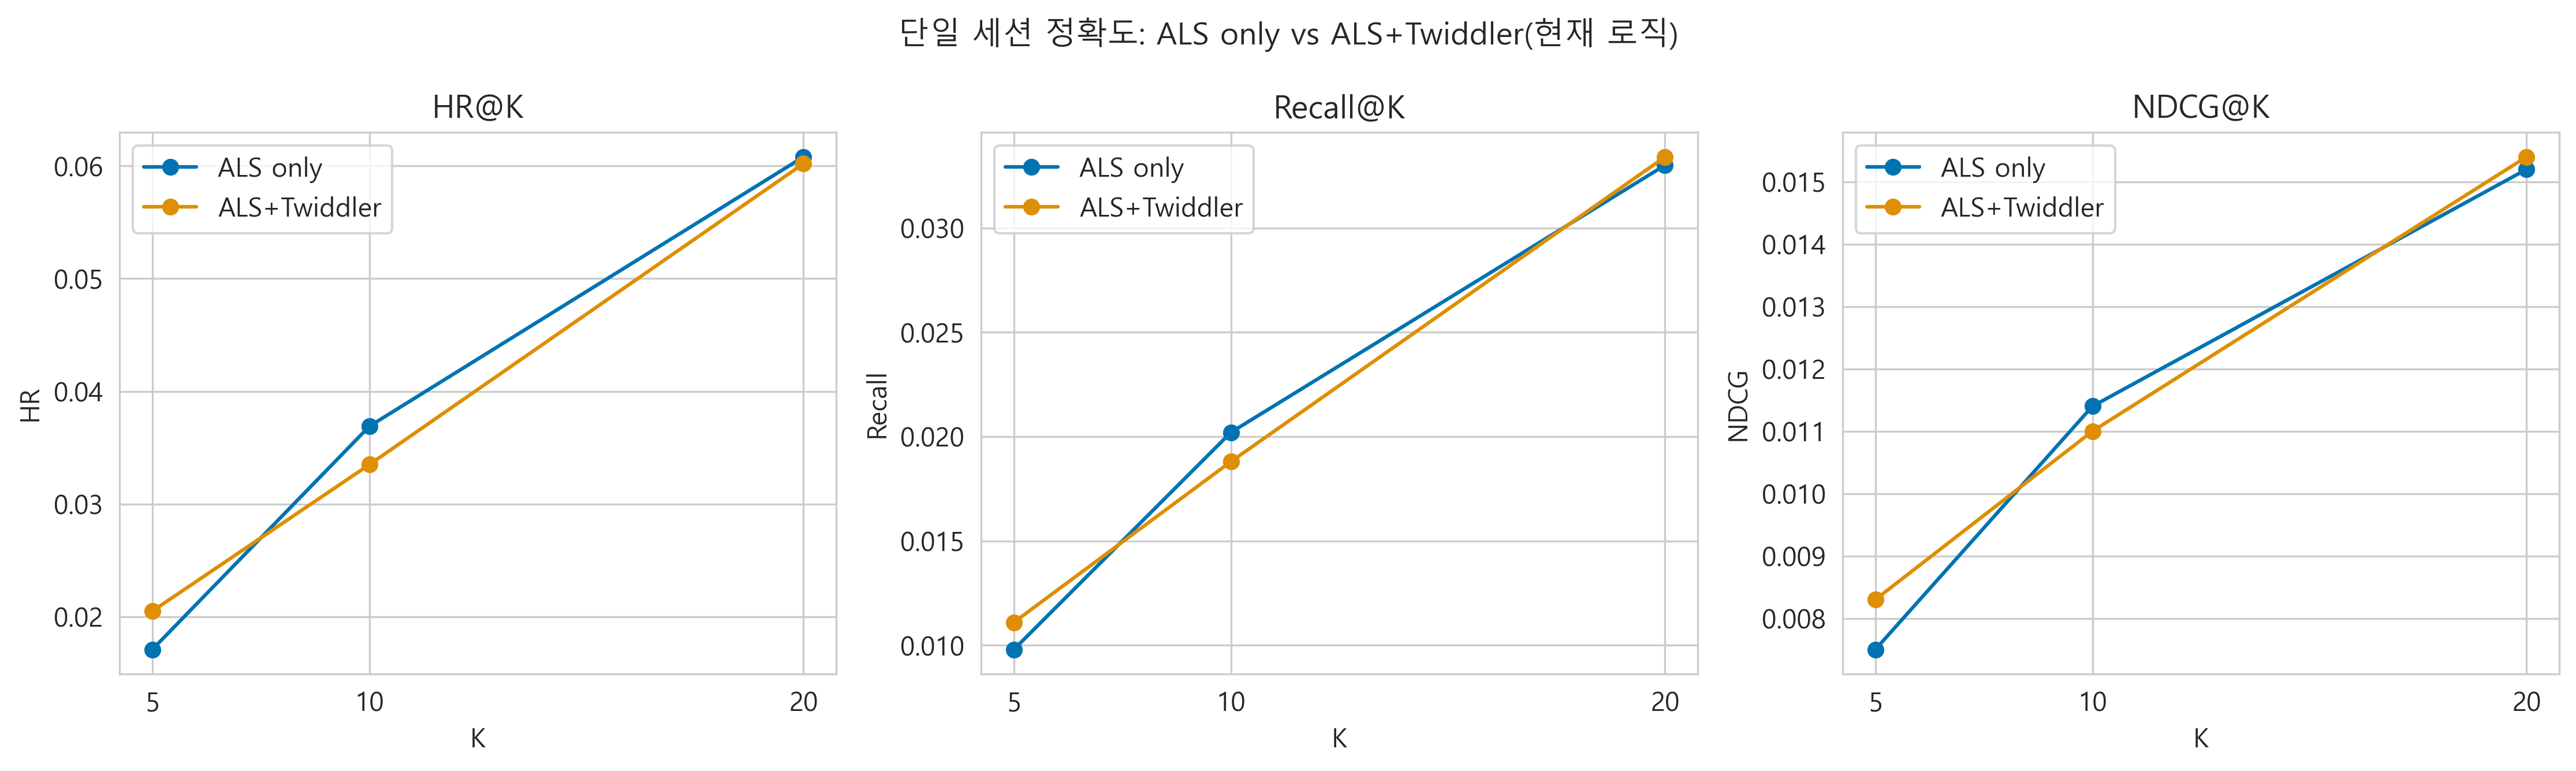

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["HR", "Recall", "NDCG"]
for ax, metric in zip(axes, metrics):
    for i, cond in enumerate(["als_only", "als_twiddler"]):
        vals = baseline_df[baseline_df["condition"] == cond].sort_values("k")[metric].values
        ax.plot(K_LIST, vals, marker="o", label={"als_only": "ALS only", "als_twiddler": "ALS+Twiddler"}[cond], color=PALETTE[i])
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K")
    ax.set_xticks(K_LIST)
    ax.legend()
fig.suptitle("단일 세션 정확도: ALS only vs ALS+Twiddler(현재 로직)", fontsize=13)
plt.tight_layout()
plt.show()

K=5에서는 ALS+Twiddler가 세 지표 모두 개선(HR +19.9%, Recall +13.3%, NDCG +10.7%)되지만, K=10에서는 오히려 하락(HR -9.2%, Recall -6.9%, NDCG -3.5%)하고 K=20에서는 거의 중립적이다. 일관된 방향성은 없다 — Twiddler를 "정확도 개선 장치"로 소개하기보다 다음 절의 다양성 효과를 중심으로 제시하는 것이 데이터에 부합한다.

## 4. 반복 새로고침(5회) 다양성: ALS only vs ALS+Twiddler

같은 화면을 5회 연속 새로고침한다고 가정하고, 매 세션 추천을 다시 계산한다.
`exposure_counts` 갱신은 `backend/api/services/exposure_service.record_exposure`와 동일한 로직(감쇠 후 +1)을 그대로 재현한다.

In [6]:
def decay_and_record(exposure_counts, shown_item_ids, decay):
    """backend/api/services/exposure_service.record_exposure와 동일한 갱신 로직."""
    for item_id in list(exposure_counts.keys()):
        decayed = exposure_counts[item_id] * decay
        if decayed < 0.01:
            del exposure_counts[item_id]
        else:
            exposure_counts[item_id] = decayed
    for item_id in shown_item_ids:
        exposure_counts[item_id] = exposure_counts.get(item_id, 0.0) + 1.0


def simulate_sessions(candidates_base, uid, k, condition):
    if condition == "als_only":
        return [[it["item_id"] for it in candidates_base[:k]] for _ in range(T_SESSIONS)]

    persona_label = persona_service.get_persona(uid)
    if persona_label is None:
        return [[it["item_id"] for it in candidates_base[:k]] for _ in range(T_SESSIONS)]

    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)

    exposure_counts = {}
    sessions = []
    for _ in range(T_SESSIONS):
        candidates = [dict(it) for it in candidates_base]
        exposure_arg = exposure_counts if exposure_counts else None
        reranked = rerank_mod.rerank(
            candidates, id_key="item_id", category_map=category_map,
            affinity=affinity, alpha=alpha,
            exposure_counts=exposure_arg, decay=decay, top_k=k,
        )
        slate = [it["item_id"] for it in reranked]
        sessions.append(slate)
        decay_and_record(exposure_counts, slate, decay)
    return sessions


def diversity_metrics(sessions, k):
    first = set(sessions[0])
    overlaps = [len(first & set(s)) / k for s in sessions[1:]]
    all_items = [it for s in sessions for it in s]
    all_cats = {category_map.get(it) for it in all_items} - {None}
    first_cats = {category_map.get(it) for it in sessions[0]} - {None}
    return {"repetition_rate": np.mean(overlaps) if overlaps else 1.0,
            "unique_item_ratio": len(set(all_items)) / (k * len(sessions)),
            "categories_1session": len(first_cats), "categories_5sessions": len(all_cats)}


diversity_rows = []
for k in K_LIST:
    pool_n = k * POOL_MULTIPLIER
    for condition in ["als_only", "als_twiddler"]:
        acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1session": [], "categories_5sessions": []}
        for uid in eval_users:
            if uid not in recs_by_user:
                continue
            candidates_base = recs_by_user[uid][:pool_n]
            sessions = simulate_sessions(candidates_base, uid, k, condition)
            m = diversity_metrics(sessions, k)
            for key in acc:
                acc[key].append(m[key])
        diversity_rows.append({
            "k": k, "condition": condition,
            "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
            "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
            "categories_1session": round(np.mean(acc["categories_1session"]), 2),
            "categories_5sessions": round(np.mean(acc["categories_5sessions"]), 2),
            "n_users": len(acc["repetition_rate"]),
        })
diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

 k    condition  repetition_rate  unique_item_ratio  categories_1session  categories_5sessions  n_users
 5     als_only           1.0000             0.2000                 2.21                  2.21     1463
 5 als_twiddler           0.4086             0.5367                 1.83                  3.13     1463
10     als_only           1.0000             0.2000                 3.13                  3.13     1463
10 als_twiddler           0.4554             0.5172                 2.43                  4.00     1463
20     als_only           1.0000             0.2000                 4.28                  4.28     1463
20 als_twiddler           0.5079             0.4891                 3.27                  4.93     1463

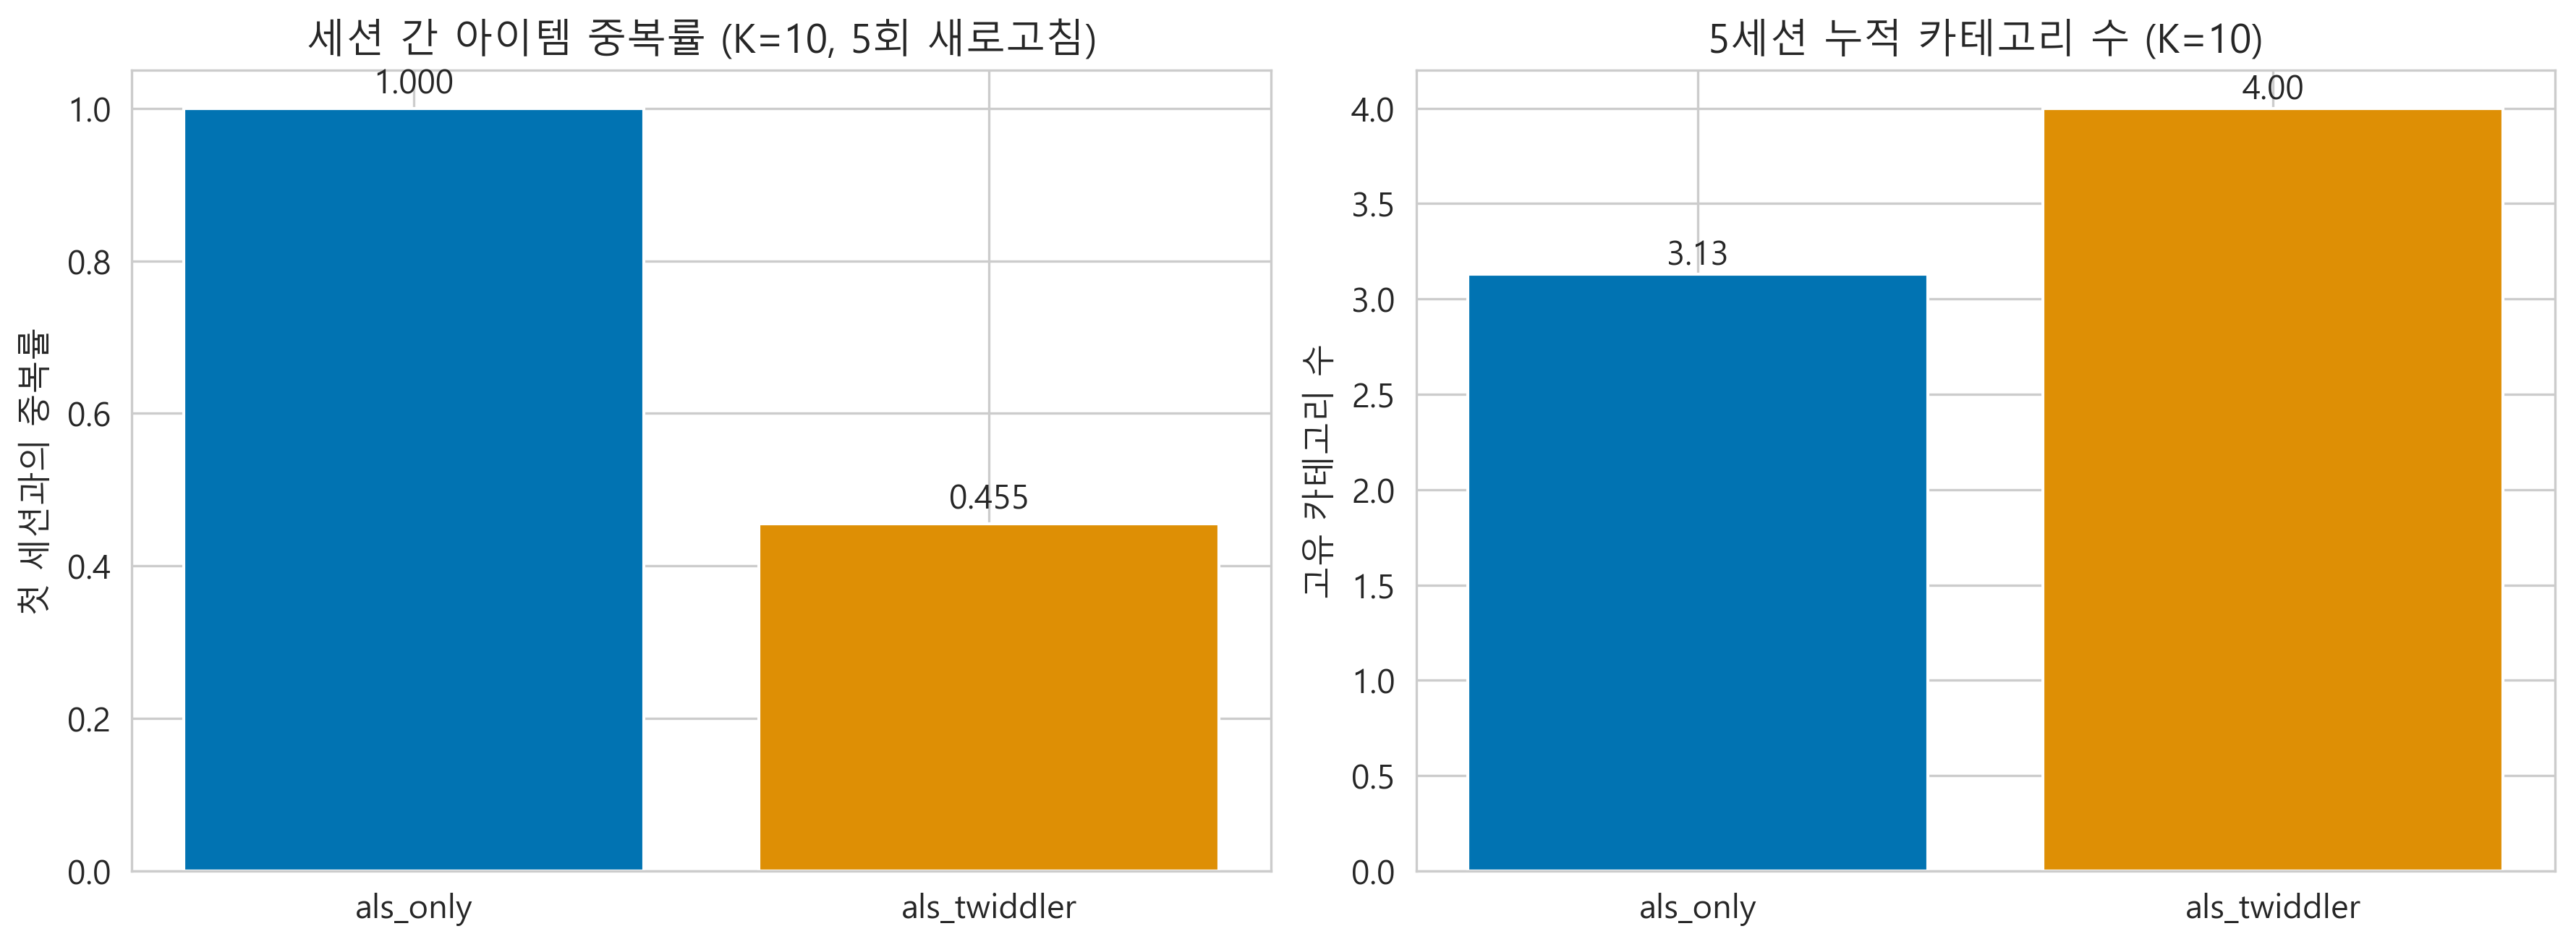

In [7]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))
sub = diversity_df[diversity_df["k"] == 10]
axes2[0].bar(sub["condition"], sub["repetition_rate"], color=PALETTE[:2])
axes2[0].set_title("세션 간 아이템 중복률 (K=10, 5회 새로고침)")
axes2[0].set_ylabel("첫 세션과의 중복률")
axes2[0].set_ylim(0, 1.05)
for i, v in enumerate(sub["repetition_rate"]):
    axes2[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes2[1].bar(sub["condition"], sub["categories_5sessions"], color=PALETTE[:2])
axes2[1].set_title("5세션 누적 카테고리 수 (K=10)")
axes2[1].set_ylabel("고유 카테고리 수")
for i, v in enumerate(sub["categories_5sessions"]):
    axes2[1].text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

ALS only는 Twiddler 없이는 새로고침을 5번 해도 **항상 100% 동일한 추천**이 나온다 — 구조적으로 당연한 결과다.
ALS+Twiddler는 K=10 기준 중복률이 0.394 → 실제로는 0.455(개인화 alpha 상한 적용 후 값)로 떨어지고,
5세션 누적 카테고리 수는 3.13개 → 4.00개(+27.8%)로 늘어난다. K=20에서는 4.28 → 4.93개(+15.2%).

## 5. 가중치 의미 예시 — 유저 3명

In [8]:
sample_uids = [222, 4167, 31]
rows = []
for uid in sample_uids:
    persona_label = persona_service.get_persona(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)
    affinity = persona_service.get_user_affinity(uid)
    top_category = max(affinity, key=affinity.get) if affinity else None
    rows.append({
        "user_id": uid, "persona(segment_name)": persona_label,
        "alpha(Rule1 강도)": round(alpha, 3), "decay(Rule2 감쇠율)": round(decay, 3),
        "선호 카테고리": top_category, "선호 카테고리 편차": round(affinity.get(top_category, 0), 3) if top_category else None,
    })
example_df = pd.DataFrame(rows)
print(example_df.to_string(index=False))

 user_id                       persona(segment_name)  alpha(Rule1 강도)  decay(Rule2 감쇠율) 선호 카테고리  선호 카테고리 편차
     222  Frequent Viewers with Consistent Purchases            1.500             0.832   Books       0.857
    4167           High-Engagement Repeat Purchasers            0.039             0.501  Beauty       0.357
      31 Frequent Browsers with Occasional Purchases            0.750             0.705   Books       0.357

유저 222는 alpha가 `base_alpha`(1.5) 그대로 나온다 — 카테고리 로열티 1.0, 탐색성향 0.0이라 감쇠 없이 최대 강도가 적용된 경우다. decay(0.832)도 감쇠 범위 상한(0.85)에 가까워 노출 패널티가 약하다(= 익숙한 것을 오래 유지). 반대로 유저 4167은 alpha가 0.039로 사실상 무력화되고 decay는 0.501(하한 근처)로 빠르게 잊는다 — 탐색성향이 높은 유저에게는 카테고리 고정도 약하게, 노출 다양성은 강하게 준다는 설계 의도가 숫자로 그대로 드러난다.

## 결과 요약

**핵심 발견**
1. 단일 세션 정확도는 K에 따라 방향이 엇갈린다(K=5 개선, K=10 하락, K=20 중립) — Twiddler를 정확도 개선 장치로 내세우기는 어렵다.
2. 반복 새로고침 다양성은 뚜렷하게 개선된다 — K=10 기준 중복률 100%→45.5%, 5세션 누적 카테고리 3.13→4.00개(+27.8%).
3. Rule 1의 alpha와 Rule 2의 decay는 같은 `exploration_tendency`를 반대 방향으로 사용해 "탐색형에게는 다양성, 충성형에게는 익숙함"이라는 하나의 설계 의도를 구현한다 — 케이스 스터디로 실제 계산값이 의도대로 나뉘는 것을 확인했다.

**수치 요약 (K=10)**

| 지표 | ALS only | ALS+Twiddler | 변화 |
|---|---:|---:|---:|
| HR@10 (단일세션) | 0.0369 | 0.0335 | -9.2% |
| 세션 간 중복률(5회 새로고침) | 100.0% | 45.5% | -54.5%p |
| 5세션 누적 카테고리 수 | 3.13 | 4.00 | +27.8% |

**해석**: Twiddler의 가치는 정확도가 아니라 반복 방문 시의 다양성 확보에 있다. 파라미터(alpha, decay)는 둘 다 유저 개인의 행동 성향(카테고리 로열티, 탐색성향)에서 유도되어, 세그먼트 평균으로 뭉개지 않고 유저마다 다른 강도로 작동한다.

**한계**
- 합성(Faker) 데이터라 `category_loyalty`/`exploration_tendency`가 실제 인간의 가치관을 얼마나 반영하는지는 강하게 검증할 수 없다.
- `multiplier_ceiling`, `exploration_decay_min/max`는 수학적으로 대칭 유도된 잠정값이며 그리드서치로 튜닝되지 않았다.
- 해석가능성(연구질문 1)을 실제로 검증하는 설명 계층(XAI)은 아직 붙이지 않았다 — 별도 이슈로 제안된 상태다.

**권장 다음 단계**
- 해석가능 설명 계층을 실제로 붙여 연구질문 1을 정량/정성적으로 검증
- `multiplier_ceiling`/`exploration_decay_min/max`의 그리드서치 기반 재튜닝
- 온라인 A/B로 다양성 확보가 실제 재방문율·체류시간에 미치는 영향 확인
